In [62]:
import sklearn.datasets as skld
import matplotlib.pyplot as plt
import numpy as np
import torch
import mnist

2.56515205023976e-05
0.005064733013930496


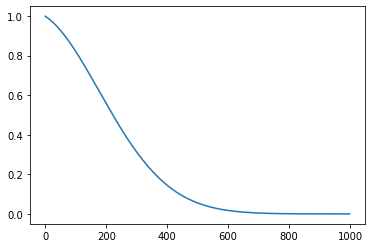

In [63]:
noise_schedule = np.linspace(0.001,0.02,1000)
print((1-noise_schedule).prod())
print((np.sqrt(1-noise_schedule)).prod())
plt.plot((1-noise_schedule).cumprod())

In [64]:
train_images = 2*(mnist.train_images().reshape(-1,28*28)/256 - 0.5)
train_labels = mnist.train_labels()

True

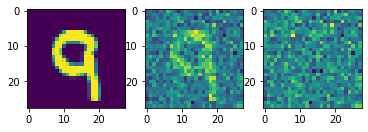

In [65]:
def corrupt_with_noise(X,t,noise):
    alphas = 1-noise_schedule
    alphabar = alphas[:t].prod()
    mean = np.sqrt(alphabar)*X
    sigma = np.sqrt(1-alphabar)
    X = mean + noise*sigma
    return torch.FloatTensor(X)

def corrupt(X,t):
    noise = torch.randn(X.shape)
    return corrupt_with_noise(X,t,noise)

def make_data(N):
    idx = np.random.choice(np.arange(train_images.shape[0]), N)
    X0 = train_images[idx]
    y0 = train_labels[idx]
    return torch.FloatTensor(X0), torch.FloatTensor(y0)

def noise_from_x0_and_xt(x0,x,t):
    alphas = torch.FloatTensor(1-noise_schedule)
    alphabar = alphas[:t].prod()
    sigma = torch.sqrt(1-alphabar)
    scale = torch.sqrt(alphabar)    
    noise = (x-scale*x0)/sigma
    return noise

X0,_ = make_data(1000)

noise = torch.randn(X0.shape)
X = corrupt_with_noise(X0,200,noise)
f,axarr = plt.subplots(1,3)
ax = axarr[0]
ax.imshow(X0[0].reshape(28,28))
ax = axarr[1]
ax.imshow(X[0].reshape(28,28))
ax = axarr[2]
ax.imshow(noise[0].reshape(28,28))
np.allclose(noise_from_x0_and_xt(X0,X,200),noise,1e-6,1e-6)

In [112]:
import torch

class DiffusionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        time_dim = 128
        cond_dim = 128
        self.diffuser = torch.nn.Sequential(
            torch.nn.Linear(28*28+time_dim + cond_dim,512),
            torch.nn.ReLU(),
            torch.nn.Linear(512,512),
            torch.nn.ReLU(),
            torch.nn.Linear(512,512),
            torch.nn.ReLU(),
            torch.nn.Linear(512,512),
            torch.nn.ReLU(),
            torch.nn.Linear(512,28*28),    
        )
        self.embed_cond = torch.nn.Embedding(11,cond_dim)
        self.embed_time = torch.nn.Linear(1,time_dim)
    
    def forward(self,Xt):
        return self.diffuser(Xt)
    
make_model = DiffusionModel

def make_Xt(X,t):
    tcol = torch.ones((X.shape[0],1))*(t/len(noise_schedule))
    Xt = torch.cat([X,tcol],dim=-1)
    return Xt

def make_XtC(model,X,t,cond):
    tcol = torch.ones((X.shape[0],1))*(t/len(noise_schedule))
    amputated = torch.LongTensor(
        np.where(np.random.uniform(0,1, size = len(cond)) > 0.5, cond, np.ones_like(cond)*10)
    )
    cond = model.embed_cond(amputated)
    time = model.embed_time(tcol)
    XtC = torch.cat([X,time,cond],dim=-1)
    return XtC

def train():   
    model = make_model()
    opt = torch.optim.Adam(model.parameters(),3e-4)
    for i in range(15000):
        X0,y0 = make_data(500)
        t = np.random.randint(1,len(noise_schedule))
        X = corrupt(X0,t)
#         cond = torch.LongTensor([10]*len(X))
        cond = y0
        XtC = make_XtC(model,X,t,y0)

        pred = model(XtC)
        loss = torch.nn.functional.mse_loss(pred,X0)
        if i % 1000 == 0:
            print(i,float(loss))
        loss.backward()
        opt.step()
        opt.zero_grad()
    return model
        
trained_model = train()

0 0.9313459992408752
1000 0.11721328645944595
2000 0.08378677070140839
3000 0.17169831693172455
4000 0.2048194706439972
5000 0.24179796874523163
6000 0.06091046333312988
7000 0.23360112309455872
8000 0.24222815036773682
9000 0.15342770516872406
10000 0.05081002041697502
11000 0.10313089191913605
12000 0.13211371004581451
13000 0.16473588347434998
14000 0.043437160551548004


In [113]:
def get_mean_sigma(xt,pred_noise,t):
    step = t
    alpha = 1-noise_schedule
    alpha_t = alpha[step]
    alphabar_t = alpha[:step].prod()

    alpha_t1 = alpha[step-1]
    alphabar_t1 = alpha[:step-1].prod()

    cond_noise,uncond_noise  = pred_noise
    w = 0.0
    pred_noise = (w+1)*cond_noise - w*uncond_noise
    xmean = 1/np.sqrt(alpha_t)*(xt-(1-alpha_t)/np.sqrt(1-alphabar_t)*pred_noise)

    sigma2 = (1-alphabar_t1)/(1-alphabar_t)*(1-alpha_t)
    return xmean,np.sqrt(sigma2)

def denoise_step(trained_model,X,t, cond_value = 4):
    with torch.no_grad():
        XtC_uncond = make_XtC(trained_model,X,t,torch.LongTensor([10]*len(X)))
        X0pred_uncond = trained_model(XtC_uncond)
        noise_pred_uncond = noise_from_x0_and_xt(X0pred_uncond,X,t)
        
        
        XtC_cond = make_XtC(trained_model,X,t,torch.LongTensor([cond_value]*len(X)))
        X0pred_cond = trained_model(XtC_cond)
        noise_pred_cond = noise_from_x0_and_xt(X0pred_cond,X,t)
        
        noise_pred = noise_pred_cond,noise_pred_uncond
    mean,sigma = get_mean_sigma(X,noise_pred,t)
    Xt1 = mean + sigma*torch.randn(X.shape)
    return Xt1

def generate(trained_model,N,steps, start = len(noise_schedule), return_trajectory = False, X = None, cond_value = 4):
    X = X if X is not None else torch.FloatTensor(np.random.normal(0,1,size = (N,28*28)))
    traj = [X]
    for i in range(1,steps):
        t = start - i
        X = denoise_step(trained_model,X,t, cond_value = cond_value)
        traj.append(X)
    if return_trajectory:
        return traj
    return X

In [92]:
def show(imgs,nrow = 4,ncol = 6):
    fig, axs = plt.subplots(nrow,ncol, squeeze=False)
    for img,ax in zip(imgs,axs.ravel()):
        img = img.detach()
        ax.imshow(np.asarray(img), vmin = -1.5,vmax = 1.5)
        ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    fig.set_tight_layout(True)
    return fig

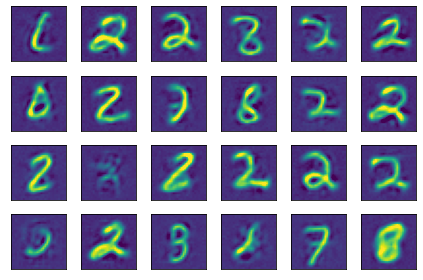

In [124]:
XG = generate(trained_model,24,999, cond_value = 2)
grid = XG.reshape(24,28,28)
f = show(grid)

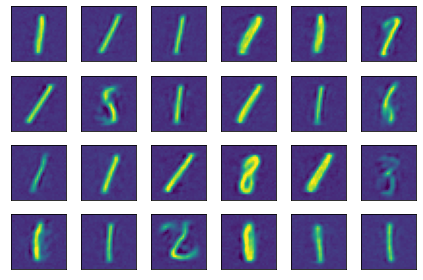

In [125]:
XG = generate(trained_model,24,999, cond_value = 1)
grid = XG.reshape(24,28,28)
f = show(grid)

In [104]:
def plot_rajectory(cond_value = 1):
    Ns = 5
    Nsteps = 8
    ats = [0,200,500,700,800,900,990,998]
    XG = generate(trained_model,Nsteps*Ns,999, return_trajectory=True, cond_value = cond_value)
    trajs = torch.stack(XG).reshape(999,Nsteps*Ns,28,28)
    f = show(np.swapaxes(trajs[np.array(ats),:Ns,:,:],0,1).reshape(XG[0].shape[0],28,28),Ns,Nsteps)
    f.set_size_inches(7,4)

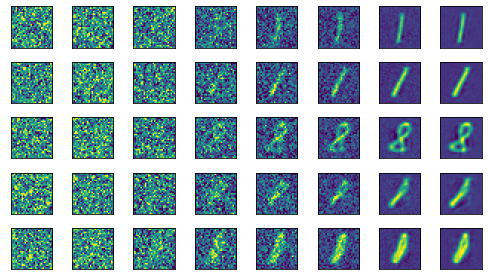

In [105]:
plot_rajectory(1)

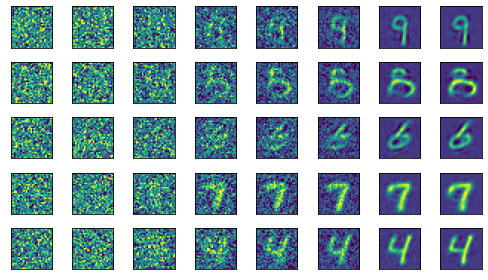

In [110]:
plot_rajectory(4)

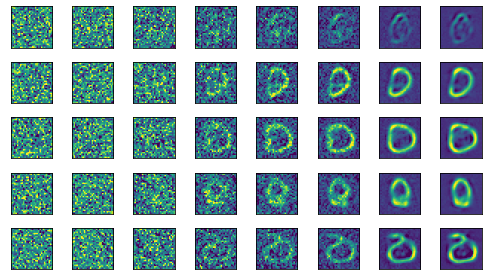

In [109]:
plot_rajectory(0)

In [126]:
!open .